In [31]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [32]:
import matplotlib.pyplot as plt

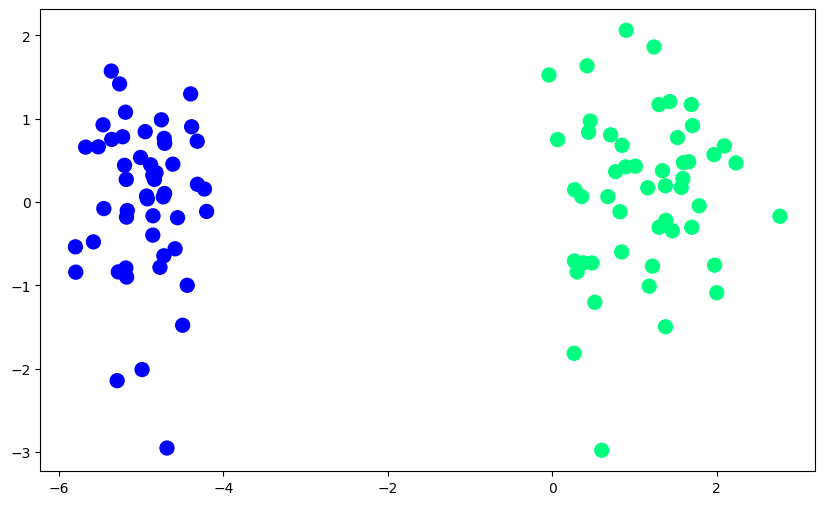

In [33]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [34]:
from sklearn.linear_model import LogisticRegression
lor=LogisticRegression(solver='sag')
lor.fit(X,y)


LogisticRegression(solver='sag')

In [35]:
m=-(lor.coef_[0][0]/lor.coef_[0][1])
b=-(lor.intercept_/lor.coef_[0][1])

In [36]:
X_input=np.linspace(-3,3,100)
Y_input=m*X_input+b

(-3.0, 2.0)

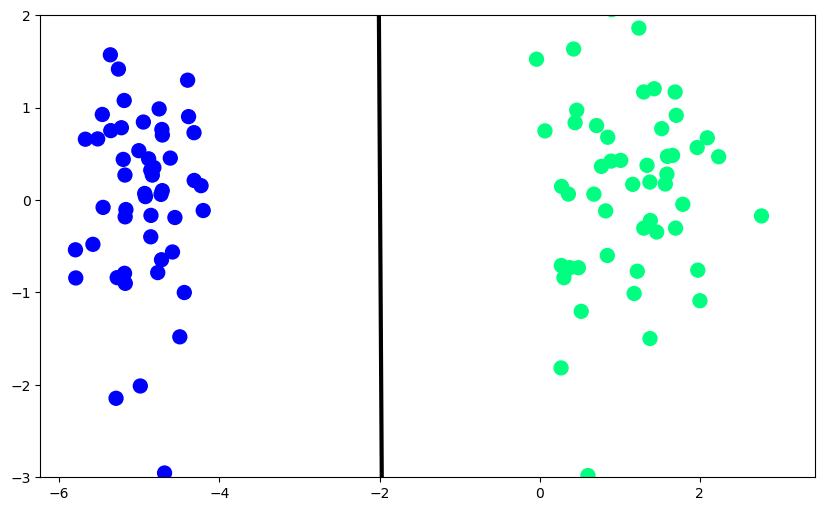

In [37]:
plt.figure(figsize=(10,6))
plt.plot(X_input,Y_input,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)


In [38]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def gd(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
    return weights[0],weights[1:]

In [39]:
intercept_,coef_=gd(X,y)

In [40]:
intercept_

5.102916648814875

In [41]:
coef_

array([3.47974267, 0.13305072])

In [42]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [43]:
X_input_gd=np.linspace(-3,3,100)
y_input_gd=m*X_input_gd+b

(-3.0, 2.0)

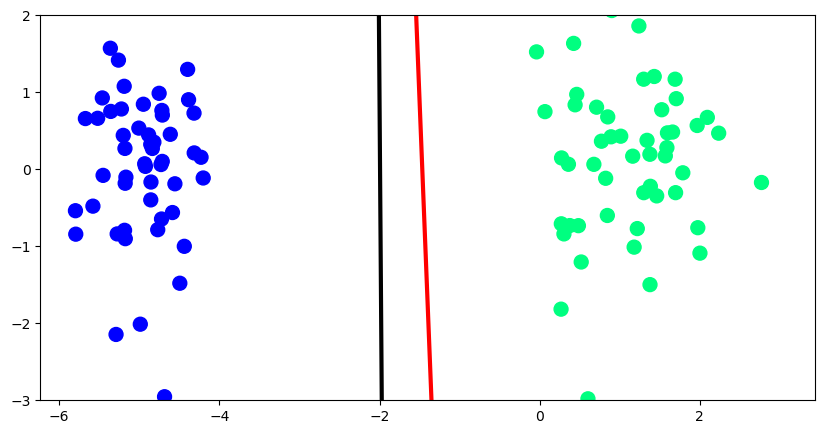

In [44]:
plt.figure(figsize=(10,5))
plt.plot(X_input,Y_input,color='black',linewidth=3)
plt.plot(X_input_gd,y_input_gd,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)